# AQI Prediction - Exploratory Data Analysis (EDA)

This notebook loads the historical feature data from the Hopsworks Feature Store
and explores trends, patterns, and correlations before we build the training pipeline.

## 1. Setup & Connect to Hopsworks

In [1]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'utils'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from hopsworks_client import get_feature_store
from config import HOPSWORKS_PROJECT_NAME, FEATURE_GROUP_NAME, FEATURE_GROUP_VERSION

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
fs = get_feature_store(HOPSWORKS_PROJECT_NAME)
fg = fs.get_feature_group(name=FEATURE_GROUP_NAME, version=FEATURE_GROUP_VERSION)

df = fg.read()
print(df.shape)
df.head()

2026-08-07 14:33:14,565 INFO: Initializing external client
2026-08-07 14:33:14,566 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-07 14:33:21,363 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/42176
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (16.86s) 
(17545, 22)


,city,timestamp,unix_time,hour,day,month,day_of_week,is_weekend,temperature,humidity,...,cloud_cover,pm2_5,pm10,o3,co,so2,no2,nh3,aqi,dominant_pollutant
0,Lahore,2026-08-06T21:00:00+00:00,1786050000,21,6,8,3,0,27.2,92,...,1,61.2,66.4,66.0,817.0,12.5,22.2,NaN,154,pm2_5
1,Lahore,2026-06-03T08:00:00+00:00,1780473600,8,3,6,2,0,35.7,34,...,9,47.1,112.5,208.0,506.0,10.8,3.0,NaN,130,pm2_5
2,Lahore,2024-12-23T17:00:00+00:00,1734973200,17,23,12,0,0,10.0,90,...,0,210.0,211.4,18.0,2980.0,40.4,77.1,NaN,260,pm2_5
3,Lahore,2026-02-17T22:00:00+00:00,1771365600,22,17,2,1,0,15.1,92,...,63,117.6,124.8,9.0,1146.0,21.6,71.1,NaN,183,pm2_5
4,Lahore,2026-02-27T12:00:00+00:00,1772193600,12,27,2,4,0,28.2,25,...,38,32.1,78.0,140.0,681.0,19.4,16.2,NaN,102,o3


## 2. Basic Checks

In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17545 entries, 0 to 17544
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   city                17545 non-null  object 
 1   timestamp           17545 non-null  object 
 2   unix_time           17545 non-null  int64  
 3   hour                17545 non-null  int64  
 4   day                 17545 non-null  int64  
 5   month               17545 non-null  int64  
 6   day_of_week         17545 non-null  int64  
 7   is_weekend          17545 non-null  int64  
 8   temperature         17545 non-null  float64
 9   humidity            17545 non-null  int64  
 10  pressure            17545 non-null  float64
 11  wind_speed          17545 non-null  float64
 12  cloud_cover         17545 non-null  int64  
 13  pm2_5               17545 non-null  float64
 14  pm10                17545 non-null  float64
 15  o3                  17545 non-null  float64
 16  co  

In [4]:
# Missing values per column
df.isnull().sum().sort_values(ascending=False)

nh3                   17545
city                      0
unix_time                 0
hour                      0
day                       0
timestamp                 0
month                     0
day_of_week               0
temperature               0
is_weekend                0
pressure                  0
wind_speed                0
cloud_cover               0
humidity                  0
pm2_5                     0
pm10                      0
co                        0
o3                        0
so2                       0
no2                       0
aqi                       0
dominant_pollutant        0
dtype: int64

In [5]:
# Summary statistics
df.describe()

,unix_time,hour,day,month,day_of_week,is_weekend,temperature,humidity,pressure,wind_speed,cloud_cover,pm2_5,pm10,o3,co,so2,no2,nh3,aqi
count,1.754500e+04,17545.000000,17545.000000,17545.000000,17545.000000,17545.000000,17545.000000,17545.00000,17545.000000,17545.000000,17545.000000,17545.000000,17545.000000,17545.000000,17545.000000,17545.000000,17545.000000,0.0,17545.000000
mean,1.754136e+09,11.500541,15.701225,6.528128,3.008207,0.287261,24.351160,64.07267,983.059709,5.925284,31.234540,70.544651,99.659419,89.912169,1460.660815,16.603785,40.389547,NaN,155.521858
std,1.823385e+07,6.922558,8.805149,3.445941,2.000667,0.452497,8.363523,23.17103,6.697339,3.479642,40.289298,51.579594,77.295201,64.196245,1318.090225,9.868143,33.841517,NaN,52.173983
min,1.722557e+09,0.000000,1.000000,1.000000,0.000000,0.000000,3.300000,5.00000,967.000000,0.000000,0.000000,3.400000,3.600000,0.000000,208.000000,0.100000,0.000000,NaN,32.000000
25%,1.738346e+09,6.000000,8.000000,4.000000,1.000000,0.000000,18.000000,47.00000,977.400000,3.500000,0.000000,35.600000,50.900000,37.000000,580.000000,10.200000,13.400000,NaN,120.000000
50%,1.754136e+09,12.000000,16.000000,7.000000,3.000000,0.000000,25.800000,68.00000,983.100000,5.400000,5.000000,54.100000,77.500000,73.000000,983.000000,13.700000,30.200000,NaN,156.000000
75%,1.769926e+09,18.000000,23.000000,10.000000,5.000000,1.000000,30.500000,83.00000,988.600000,7.800000,70.000000,87.800000,126.200000,142.000000,1848.000000,20.000000,60.700000,NaN,181.000000
max,1.786050e+09,23.000000,31.000000,12.000000,6.000000,1.000000,46.500000,100.00000,1001.500000,29.300000,100.000000,365.100000,890.300000,279.000000,11482.000000,94.400000,201.900000,NaN,500.000000


In [6]:
# Make sure the data is sorted by time - important for time-series analysis
df = df.sort_values('unix_time').reset_index(drop=True)
df['datetime'] = pd.to_datetime(df['unix_time'], unit='s')
df[['datetime', 'aqi', 'pm2_5', 'temperature']].head()

,datetime,aqi,pm2_5,temperature
0,2024-08-02 00:00:00,99,35.0,26.0
1,2024-08-02 01:00:00,102,35.9,26.8
2,2024-08-02 02:00:00,105,37.0,27.8
3,2024-08-02 03:00:00,104,36.9,29.0
4,2024-08-02 04:00:00,98,34.6,30.3


## 3. Target Variable: AQI Distribution

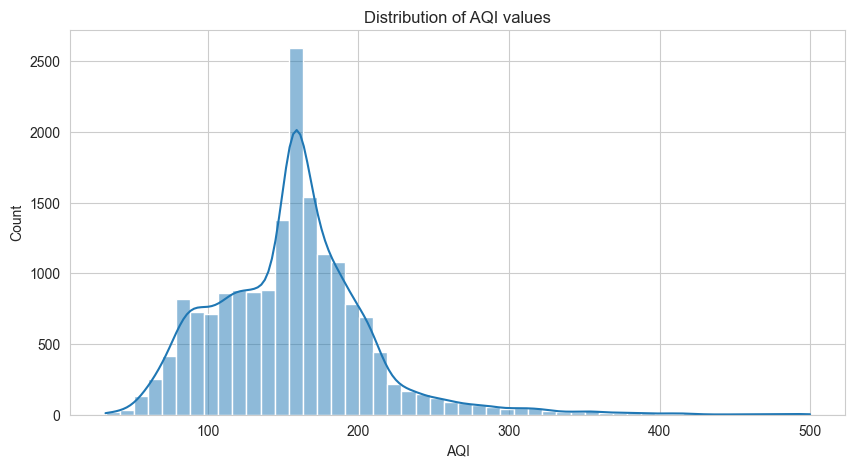

count    17545.000000
mean       155.521858
std         52.173983
min         32.000000
25%        120.000000
50%        156.000000
75%        181.000000
max        500.000000
Name: aqi, dtype: float64


In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['aqi'], bins=50, kde=True)
plt.title('Distribution of AQI values')
plt.xlabel('AQI')
plt.ylabel('Count')
plt.show()

print(df['aqi'].describe())

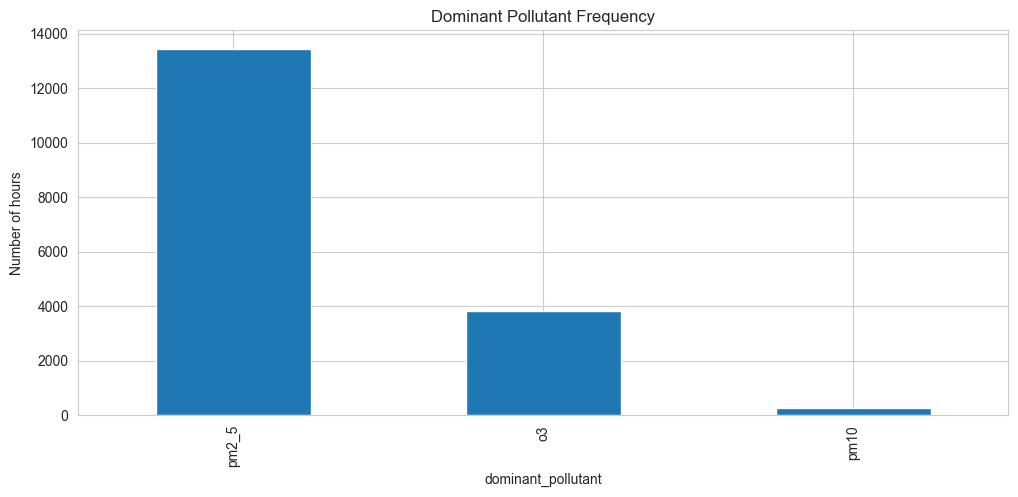

In [8]:
# How often is each pollutant the dominant one?
df['dominant_pollutant'].value_counts().plot(kind='bar')
plt.title('Dominant Pollutant Frequency')
plt.ylabel('Number of hours')
plt.show()

## 4. AQI Trend Over Time (Full 2 Years)

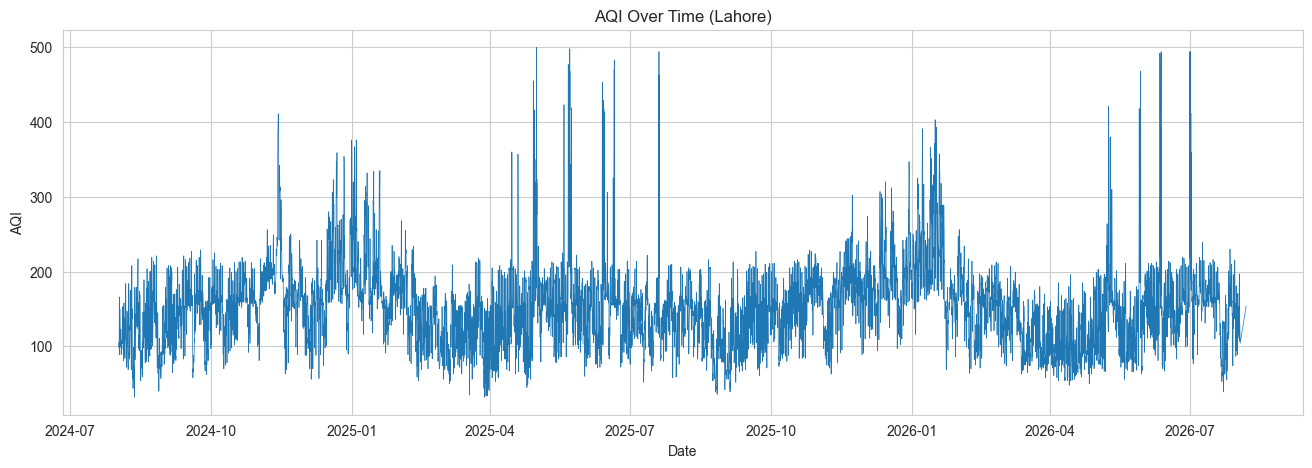

In [9]:
plt.figure(figsize=(16, 5))
plt.plot(df['datetime'], df['aqi'], linewidth=0.5)
plt.title('AQI Over Time (Lahore)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.show()

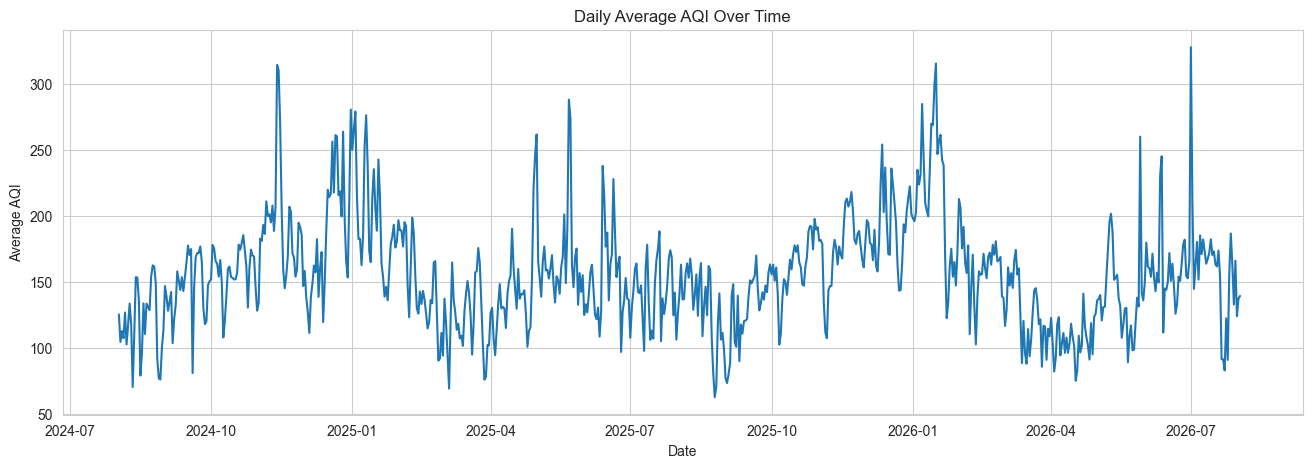

In [10]:
# Smoothed daily average - easier to see the seasonal pattern
daily_avg = df.set_index('datetime')['aqi'].resample('D').mean()

plt.figure(figsize=(16, 5))
plt.plot(daily_avg.index, daily_avg.values)
plt.title('Daily Average AQI Over Time')
plt.xlabel('Date')
plt.ylabel('Average AQI')
plt.show()

## 5. Hour-of-Day Pattern

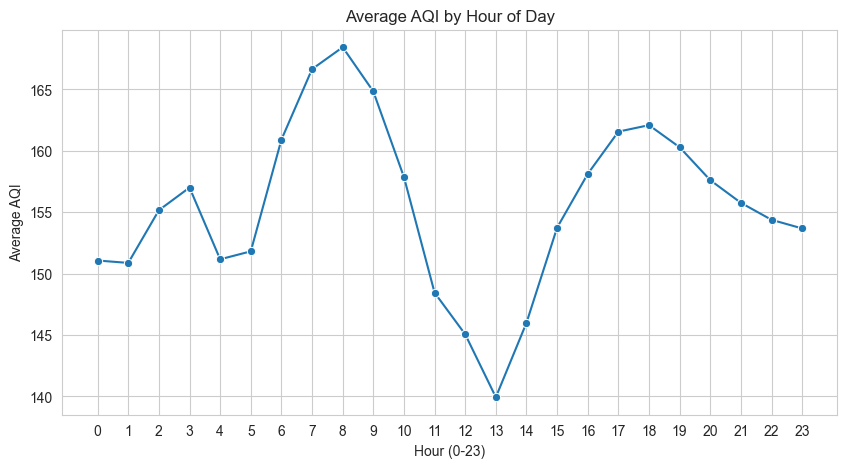

In [11]:
hourly_avg = df.groupby('hour')['aqi'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker='o')
plt.title('Average AQI by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Average AQI')
plt.xticks(range(0, 24))
plt.show()

## 6. Month-of-Year Pattern (Seasonality)

2026-08-07 14:36:05,240 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-07 14:36:05,248 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


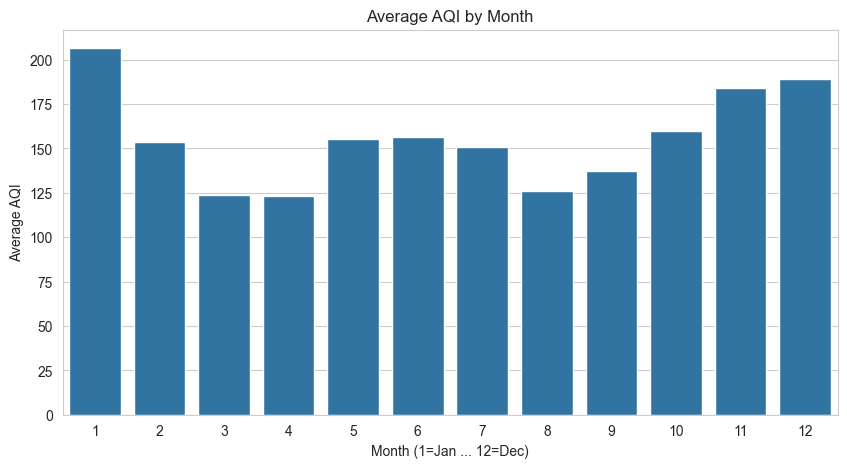

In [12]:
monthly_avg = df.groupby('month')['aqi'].mean()

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values)
plt.title('Average AQI by Month')
plt.xlabel('Month (1=Jan ... 12=Dec)')
plt.ylabel('Average AQI')
plt.show()

## 7. Weekday vs Weekend

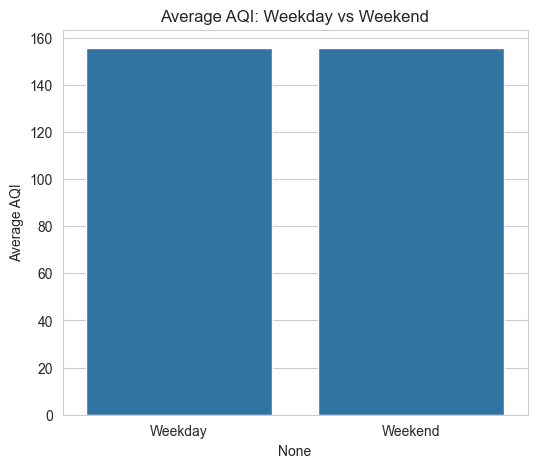

In [13]:
weekend_avg = df.groupby('is_weekend')['aqi'].mean()
weekend_avg.index = ['Weekday', 'Weekend']

plt.figure(figsize=(6, 5))
sns.barplot(x=weekend_avg.index, y=weekend_avg.values)
plt.title('Average AQI: Weekday vs Weekend')
plt.ylabel('Average AQI')
plt.show()

## 8. Correlation Heatmap

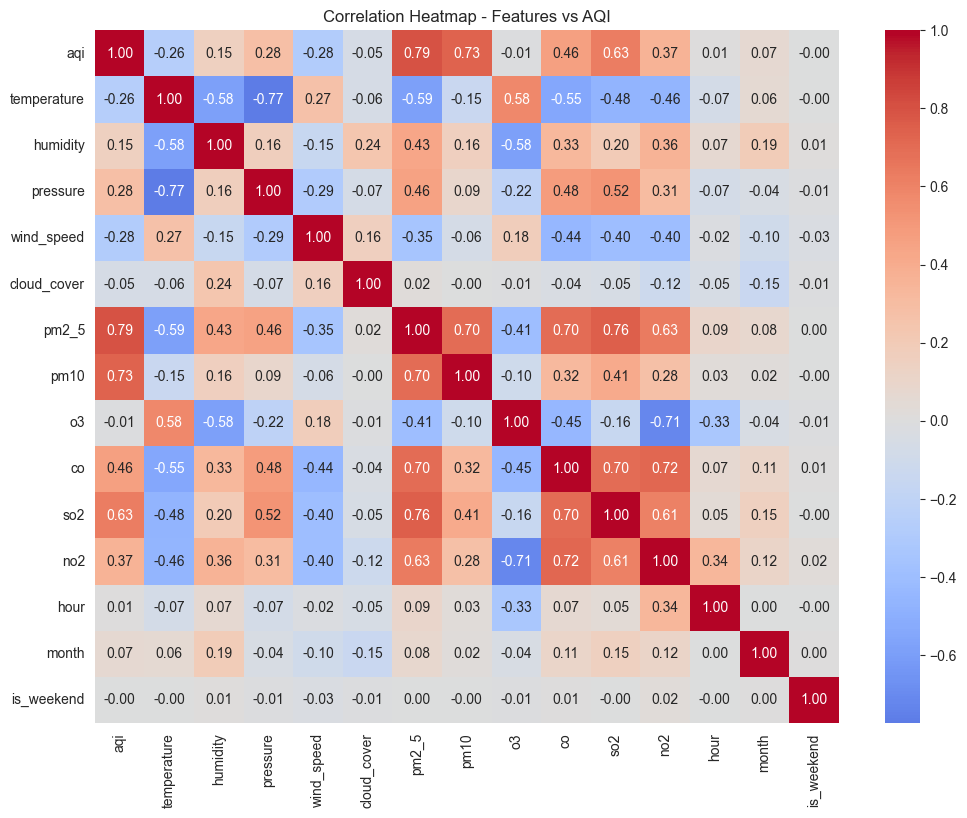

In [16]:
numeric_cols = ['aqi', 'temperature', 'humidity', 'pressure', 'wind_speed',
                 'cloud_cover', 'pm2_5', 'pm10', 'o3', 'co', 'so2', 'no2',
                 'hour', 'month', 'is_weekend']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Features vs AQI')
plt.show()

In [15]:
# Which features correlate most strongly with AQI specifically?
corr['aqi'].sort_values(ascending=False)

aqi            1.000000
pm2_5          0.794386
pm10           0.730865
so2            0.632134
co             0.462026
no2            0.368609
pressure       0.280516
humidity       0.151156
month          0.070487
hour           0.005885
is_weekend    -0.000285
o3            -0.009514
cloud_cover   -0.054509
temperature   -0.258303
wind_speed    -0.284360
Name: aqi, dtype: float64

## 9. Notes / Observations

_(Fill this in after looking at the plots above - e.g. which hours/months are worst,
which features correlate most with AQI, anything surprising in the data.)_